In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MIoU_ZS_PATH = "../inference/clipseg_cloudsen12plus_zs/miou_clipseg_cloudsen12plus_zs_eval.csv"
MIoU_LORA_PATH = "../inference/clipseg_cloudsen12plus_lora/miou_clipseg_cloudsen12plus_lora_eval.csv"
MIoU_FT_PATH = "../inference/clipseg_cloudsen12plus_fft/miou_clipseg_cloudsen12plus_fft_eval.csv"

CM_ZS_PATH = "../inference/clipseg_cloudsen12plus_zs/cm_clipseg_cloudsen12plus_zs_eval.csv"
CM_LORA_PATH = "../inference/clipseg_cloudsen12plus_lora/cm_clipseg_cloudsen12plus_lora_eval.csv"
CM_FT_PATH = "../inference/clipseg_cloudsen12plus_fft/cm_clipseg_cloudsen12plus_fft_eval.csv"

CLASS_NAMES = ["clear", "thick_cloud", "thin_cloud", "cloud_shadow"]
N_CLASSES = len(CLASS_NAMES)


In [2]:
miou_zs = pd.read_csv(MIoU_ZS_PATH)
miou_lora = pd.read_csv(MIoU_LORA_PATH)
miou_ft = pd.read_csv(MIoU_FT_PATH)

cm_zs = pd.read_csv(CM_ZS_PATH)
cm_lora = pd.read_csv(CM_LORA_PATH)
cm_ft = pd.read_csv(CM_FT_PATH)

In [3]:
ids_zs = set(miou_zs["id"]) - {"__aggregate__"}
ids_l = set(miou_lora["id"]) - {"__aggregate__"}
ids_f = set(miou_ft["id"]) - {"__aggregate__"}

common_ids = sorted(list(ids_zs & ids_l & ids_f))

print("ZS images:", len(ids_zs))
print("LoRA images:", len(ids_l))
print("FullFT images:", len(ids_f))
print("Common images (all 3):", len(common_ids))


ZS images: 975
LoRA images: 975
FullFT images: 975
Common images (all 3): 975


In [4]:
miou_zs_p = miou_zs[miou_zs["id"].isin(common_ids)].copy()
miou_lora_p = miou_lora[miou_lora["id"].isin(common_ids)].copy()
miou_ft_p = miou_ft[miou_ft["id"].isin(common_ids)].copy()

cm_zs_p = cm_zs[cm_zs["id"].isin(common_ids)].copy()
cm_lora_p = cm_lora[cm_lora["id"].isin(common_ids)].copy()
cm_ft_p = cm_ft[cm_ft["id"].isin(common_ids)].copy()

def confusion_from_row(row, n=N_CLASSES, prefix="cm_"):
    m = np.zeros((n, n), dtype=np.int64)
    for i in range(n):
        for j in range(n):
            col = f"{prefix}t{i}_p{j}"
            m[i, j] = int(row[col])
    return m

def aggregate_confusion(df, n=N_CLASSES):
    mats = []
    for _, r in df.iterrows():
        mats.append(confusion_from_row(r, n=n))
    return np.sum(mats, axis=0)

CM_ZS_GLOBAL = aggregate_confusion(cm_zs_p)
CM_LORA_GLOBAL = aggregate_confusion(cm_lora_p)
CM_FT_GLOBAL = aggregate_confusion(cm_ft_p)


In [5]:
CM_ZS_GLOBAL, CM_LORA_GLOBAL, CM_FT_GLOBAL

(array([[80135845,  7794025, 34259639, 14078306],
        [ 5013861, 23687361, 36511317,  7863275],
        [ 5771701,  2278202,  9081365,  4853800],
        [ 6896402,  2272701,  8328250,  6764350]]),
 array([[125430879,   4643588,   3119564,   3073784],
        [  3911143,  64660661,   1898798,   2605212],
        [  5977188,   4412933,  10686549,    908398],
        [  5524343,   4225570,    973499,  13538291]]),
 array([[126541578,   2652587,   3305435,   3768215],
        [  3553194,  64227166,   2340359,   2955095],
        [  4322447,   3082531,  13386653,   1193437],
        [  4023266,   2752081,    840542,  16645814]]))

In [6]:
def metrics_from_confusion(cm, class_names=CLASS_NAMES):
    cm = cm.astype(np.int64)
    total = cm.sum()
    tp = np.diag(cm)
    row_sum = cm.sum(axis=1)
    col_sum = cm.sum(axis=0)
    fn = row_sum - tp
    fp = col_sum - tp

    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)
    f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(tp, dtype=float), where=(precision + recall) != 0)
    iou = np.divide(tp, tp + fp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fp + fn) != 0)
    dice = np.divide(2 * tp, 2 * tp + fp + fn, out=np.zeros_like(tp, dtype=float), where=(2 * tp + fp + fn) != 0)

    pixel_acc = float(tp.sum() / total) if total else 0.0
    miou_macro = float(np.mean(iou))
    miou_freq = float(np.sum(iou * row_sum) / np.sum(row_sum)) if np.sum(row_sum) else 0.0
    bal_acc = float(np.mean(recall))

    per_class = pd.DataFrame({
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "dice": dice,
        "support_pixels": row_sum
    }, index=class_names)

    summary = pd.Series({
        "pixel_acc": pixel_acc,
        "mIoU_macro": miou_macro,
        "mIoU_freq_weighted": miou_freq,
        "balanced_acc": bal_acc,
        "total_pixels": int(total)
    })
    return summary, per_class


In [7]:
zs_summary, zs_pc = metrics_from_confusion(CM_ZS_GLOBAL)
l_summary, l_pc = metrics_from_confusion(CM_LORA_GLOBAL)
f_summary, f_pc = metrics_from_confusion(CM_FT_GLOBAL)

summary_df = pd.DataFrame(
    [zs_summary, l_summary, f_summary],
    index=["zero_shot", "lora", "full_finetune"]
)
summary_df


,pixel_acc,mIoU_macro,mIoU_freq_weighted,balanced_acc,total_pixels
zero_shot,0.468206,0.255040,0.377109,0.401025,255590400.0
lora,0.838515,0.599132,0.729473,0.712352,255590400.0
full_finetune,0.863887,0.657245,0.770024,0.775632,255590400.0


In [8]:
per_class_df = (
    zs_pc.add_prefix("zs_")
    .join(l_pc.add_prefix("lora_"))
    .join(f_pc.add_prefix("ft_"))
)

per_class_df["delta_iou_lora_vs_zs"] = per_class_df["lora_iou"] - per_class_df["zs_iou"]
per_class_df["delta_iou_ft_vs_zs"] = per_class_df["ft_iou"] - per_class_df["zs_iou"]
per_class_df["delta_iou_ft_vs_lora"] = per_class_df["ft_iou"] - per_class_df["lora_iou"]

per_class_df["delta_f1_lora_vs_zs"] = per_class_df["lora_f1"] - per_class_df["zs_f1"]
per_class_df["delta_f1_ft_vs_zs"] = per_class_df["ft_f1"] - per_class_df["zs_f1"]
per_class_df["delta_f1_ft_vs_lora"] = per_class_df["ft_f1"] - per_class_df["lora_f1"]

per_class_df.sort_values("delta_iou_ft_vs_zs", ascending=False)


,zs_precision,zs_recall,zs_f1,zs_iou,zs_dice,zs_support_pixels,lora_precision,lora_recall,lora_f1,lora_iou,...,ft_f1,ft_iou,ft_dice,ft_support_pixels,delta_iou_lora_vs_zs,delta_iou_ft_vs_zs,delta_iou_ft_vs_lora,delta_f1_lora_vs_zs,delta_f1_ft_vs_zs,delta_f1_ft_vs_lora
thick_cloud,0.657393,0.324148,0.434200,0.277302,0.434200,73075814,0.829592,0.884844,0.856327,0.748752,...,0.881090,0.787455,0.881090,73075814,0.471450,0.510152,0.038702,0.422127,0.446891,0.024763
cloud_shadow,0.201562,0.278808,0.233974,0.132486,0.233974,24261703,0.672687,0.558011,0.610006,0.438855,...,0.681866,0.517297,0.681866,24261703,0.306369,0.384811,0.078442,0.376032,0.447893,0.071860
thin_cloud,0.102986,0.413070,0.164867,0.089840,0.164867,21985068,0.640741,0.486082,0.552798,0.381977,...,0.639621,0.470179,0.639621,21985068,0.292138,0.380339,0.088202,0.387931,0.474754,0.086823
clear,0.819236,0.588076,0.684671,0.520532,0.684671,136267815,0.890569,0.920473,0.905274,0.826941,...,0.921280,0.854049,0.921280,136267815,0.306409,0.333516,0.027107,0.220603,0.236608,0.016005


In [9]:
def plot_confusion(cm, title, normalize="true"):
    cm = cm.astype(float)
    if normalize == "true":
        denom = cm.sum(axis=1, keepdims=True)
    elif normalize == "pred":
        denom = cm.sum(axis=0, keepdims=True)
    else:
        denom = 1.0

    cmn = np.divide(cm, denom, out=np.zeros_like(cm), where=denom != 0)

    plt.figure(figsize=(6, 5))
    plt.imshow(cmn)
    plt.title(title)
    plt.xticks(range(N_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(range(N_CLASSES), CLASS_NAMES)
    plt.colorbar(label="fraction")

    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            plt.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center")

    plt.tight_layout()
    plt.show()

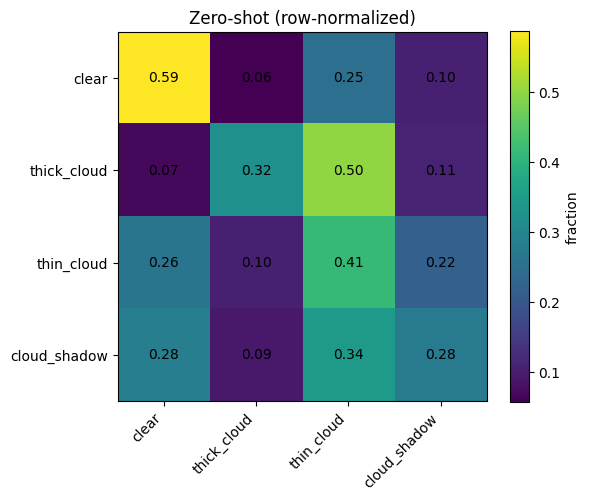

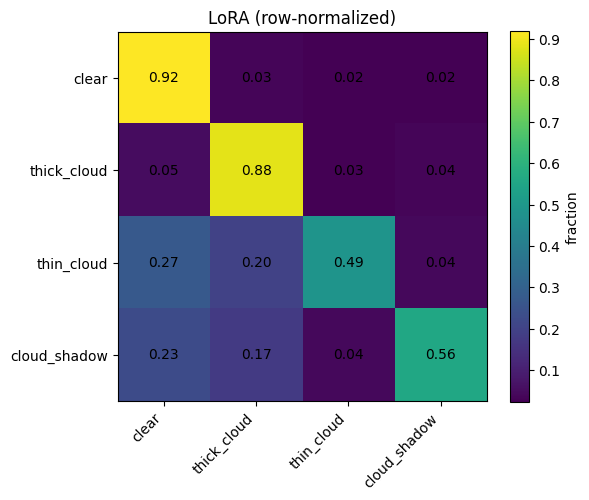

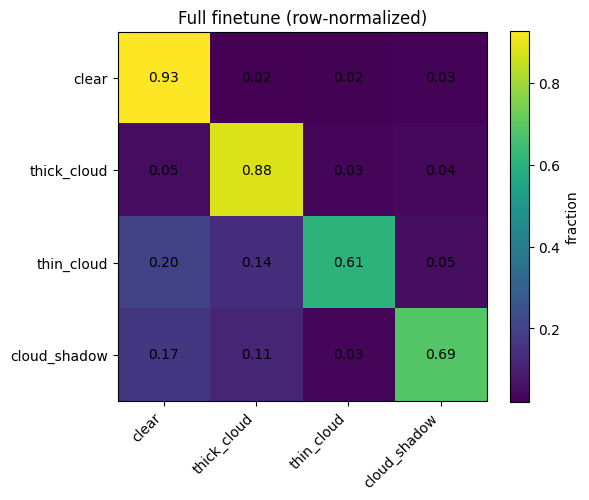

In [10]:
plot_confusion(CM_ZS_GLOBAL, "Zero-shot (row-normalized)", normalize="true")
plot_confusion(CM_LORA_GLOBAL, "LoRA (row-normalized)", normalize="true")
plot_confusion(CM_FT_GLOBAL, "Full finetune (row-normalized)", normalize="true")

In [11]:
miou_zs_p = miou_zs_p.set_index("id").loc[common_ids].reset_index()
miou_lora_p = miou_lora_p.set_index("id").loc[common_ids].reset_index()
miou_ft_p = miou_ft_p.set_index("id").loc[common_ids].reset_index()

mzs = pd.to_numeric(miou_zs_p["miou"], errors="coerce")
ml = pd.to_numeric(miou_lora_p["miou"], errors="coerce")
mf = pd.to_numeric(miou_ft_p["miou"], errors="coerce")

d_lora_zs = ml - mzs
d_ft_zs = mf - mzs
d_ft_lora = mf - ml

print("Mean mIoU (ZS):", float(mzs.mean()))
print("Mean mIoU (LoRA):", float(ml.mean()))
print("Mean mIoU (FullFT):", float(mf.mean()))
print()

print("Mean ΔmIoU (LoRA - ZS):", float(d_lora_zs.mean()))
print("Median ΔmIoU (LoRA - ZS):", float(d_lora_zs.median()))
print("Images improved % (LoRA > ZS):", float((d_lora_zs > 0).mean() * 100))
print()

print("Mean ΔmIoU (FullFT - ZS):", float(d_ft_zs.mean()))
print("Median ΔmIoU (FullFT - ZS):", float(d_ft_zs.median()))
print("Images improved % (FullFT > ZS):", float((d_ft_zs > 0).mean() * 100))
print()

print("Mean ΔmIoU (FullFT - LoRA):", float(d_ft_lora.mean()))
print("Median ΔmIoU (FullFT - LoRA):", float(d_ft_lora.median()))
print("Images improved % (FullFT > LoRA):", float((d_ft_lora > 0).mean() * 100))


Mean mIoU (ZS): 0.2120945548726987
Mean mIoU (LoRA): 0.561772737860089
Mean mIoU (FullFT): 0.6023147027539056

Mean ΔmIoU (LoRA - ZS): 0.3496781829873903
Median ΔmIoU (LoRA - ZS): 0.3156355296474742
Images improved % (LoRA > ZS): 96.0

Mean ΔmIoU (FullFT - ZS): 0.3902201478812069
Median ΔmIoU (FullFT - ZS): 0.37090929698476016
Images improved % (FullFT > ZS): 96.92307692307692

Mean ΔmIoU (FullFT - LoRA): 0.040541964893816625
Median ΔmIoU (FullFT - LoRA): 0.03817702897219699
Images improved % (FullFT > LoRA): 66.05128205128206


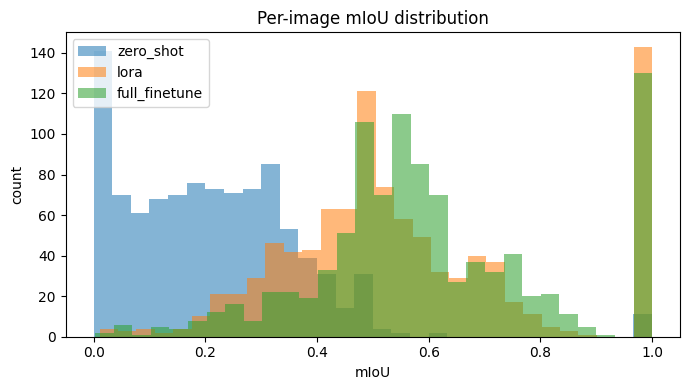

In [13]:
plt.figure(figsize=(7, 4))
plt.hist(mzs.dropna(), bins=30, alpha=0.55, label="zero_shot")
plt.hist(ml.dropna(), bins=30, alpha=0.55, label="lora")
plt.hist(mf.dropna(), bins=30, alpha=0.55, label="full_finetune")
plt.title("Per-image mIoU distribution")
plt.xlabel("mIoU")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

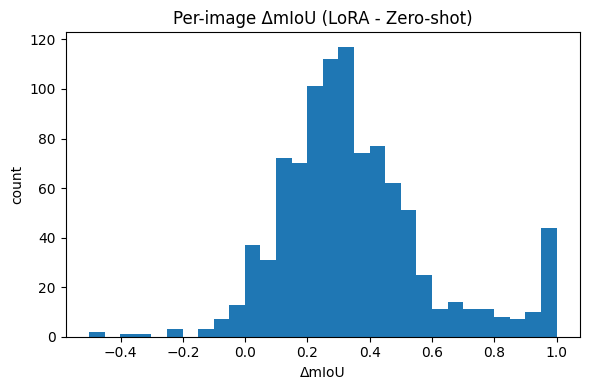

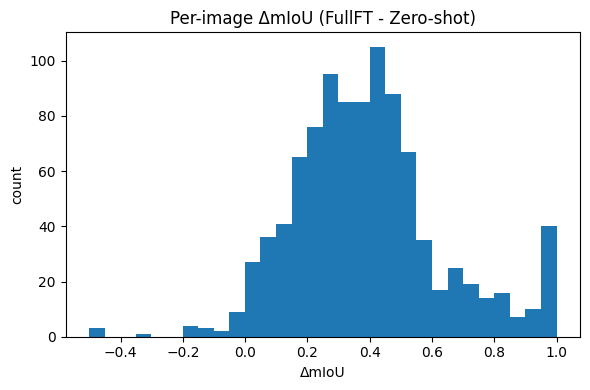

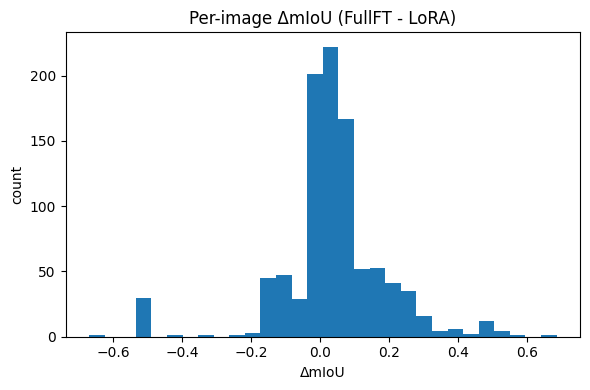

In [14]:
plt.figure(figsize=(6, 4))
plt.hist(d_lora_zs.dropna(), bins=30)
plt.title("Per-image ΔmIoU (LoRA - Zero-shot)")
plt.xlabel("ΔmIoU")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(d_ft_zs.dropna(), bins=30)
plt.title("Per-image ΔmIoU (FullFT - Zero-shot)")
plt.xlabel("ΔmIoU")
plt.ylabel("count")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(d_ft_lora.dropna(), bins=30)
plt.title("Per-image ΔmIoU (FullFT - LoRA)")
plt.xlabel("ΔmIoU")
plt.ylabel("count")
plt.tight_layout()
plt.show()


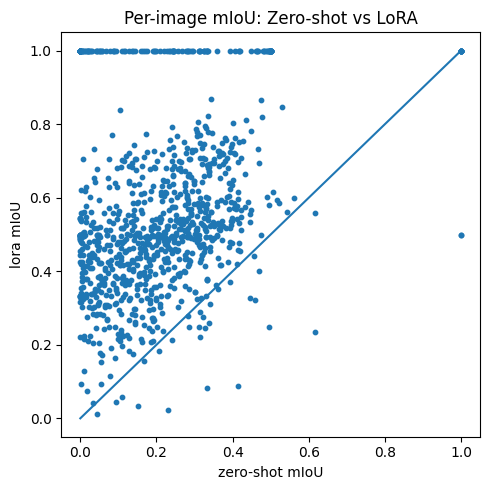

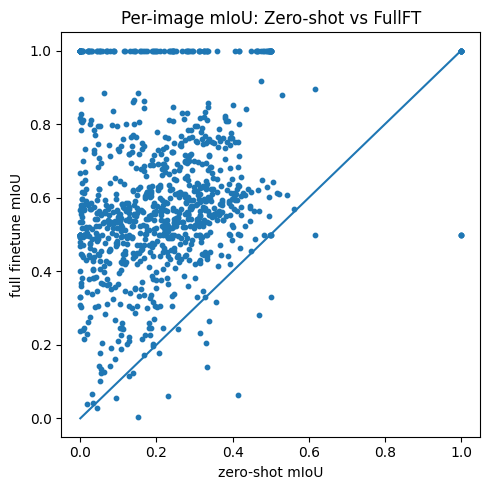

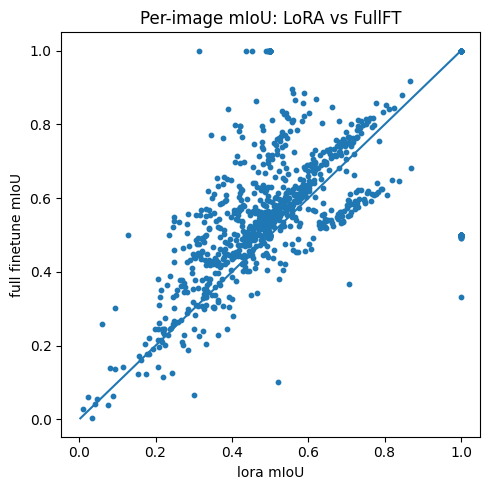

In [15]:
def scatter_compare(x, y, xlab, ylab, title):
    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, s=10)
    mn = float(np.nanmin([x.min(), y.min()]))
    mx = float(np.nanmax([x.max(), y.max()]))
    plt.plot([mn, mx], [mn, mx])  # diagonal
    plt.title(title)
    plt.xlabel(xlab)
    plt.ylabel(ylab)
    plt.tight_layout()
    plt.show()

scatter_compare(mzs, ml, "zero-shot mIoU", "lora mIoU", "Per-image mIoU: Zero-shot vs LoRA")
scatter_compare(mzs, mf, "zero-shot mIoU", "full finetune mIoU", "Per-image mIoU: Zero-shot vs FullFT")
scatter_compare(ml, mf, "lora mIoU", "full finetune mIoU", "Per-image mIoU: LoRA vs FullFT")


In [16]:
rng = np.random.default_rng(0)

def bootstrap_ci_mean(x, n_boot=5000, alpha=0.05):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    m = len(x)
    means = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        samp = rng.choice(x, size=m, replace=True)
        means[i] = samp.mean()
    lo = np.quantile(means, alpha / 2)
    hi = np.quantile(means, 1 - alpha / 2)
    return float(x.mean()), float(lo), float(hi)

mean_diff_lz, lo_lz, hi_lz = bootstrap_ci_mean(d_lora_zs.to_numpy())
mean_diff_fz, lo_fz, hi_fz = bootstrap_ci_mean(d_ft_zs.to_numpy())
mean_diff_fl, lo_fl, hi_fl = bootstrap_ci_mean(d_ft_lora.to_numpy())

print(f"Mean ΔmIoU (LoRA - ZS)     = {mean_diff_lz:.4f} (95% CI: [{lo_lz:.4f}, {hi_lz:.4f}])")
print(f"Mean ΔmIoU (FullFT - ZS)   = {mean_diff_fz:.4f} (95% CI: [{lo_fz:.4f}, {hi_fz:.4f}])")
print(f"Mean ΔmIoU (FullFT - LoRA) = {mean_diff_fl:.4f} (95% CI: [{lo_fl:.4f}, {hi_fl:.4f}])")

Mean ΔmIoU (LoRA - ZS)     = 0.3497 (95% CI: [0.3345, 0.3646])
Mean ΔmIoU (FullFT - ZS)   = 0.3902 (95% CI: [0.3756, 0.4053])
Mean ΔmIoU (FullFT - LoRA) = 0.0405 (95% CI: [0.0306, 0.0504])


In [17]:
per_class_cols = [c for c in miou_zs_p.columns if c.startswith("iou_")]
per_class_cols


['iou_clear', 'iou_thick_cloud', 'iou_thin_cloud', 'iou_cloud_shadow']

In [18]:
rows = []
for col in per_class_cols:
    a = pd.to_numeric(miou_zs_p[col], errors="coerce")
    b = pd.to_numeric(miou_lora_p[col], errors="coerce")
    c = pd.to_numeric(miou_ft_p[col], errors="coerce")

    db = b - a           # LoRA - ZS
    dc = c - a           # FullFT - ZS
    dcl = c - b          # FullFT - LoRA

    rows.append({
        "metric": col,
        "zs_mean": float(a.mean()),
        "lora_mean": float(b.mean()),
        "ft_mean": float(c.mean()),
        "delta_lora_vs_zs_mean": float(db.mean()),
        "delta_ft_vs_zs_mean": float(dc.mean()),
        "delta_ft_vs_lora_mean": float(dcl.mean()),
        "delta_lora_vs_zs_median": float(db.median()),
        "delta_ft_vs_zs_median": float(dc.median()),
        "delta_ft_vs_lora_median": float(dcl.median()),
        "improved_lora_vs_zs_%": float((db > 0).mean() * 100),
        "improved_ft_vs_zs_%": float((dc > 0).mean() * 100),
        "improved_ft_vs_lora_%": float((dcl > 0).mean() * 100),
    })

pd.DataFrame(rows).sort_values("delta_ft_vs_zs_mean", ascending=False)


,metric,zs_mean,lora_mean,ft_mean,delta_lora_vs_zs_mean,delta_ft_vs_zs_mean,delta_ft_vs_lora_mean,delta_lora_vs_zs_median,delta_ft_vs_zs_median,delta_ft_vs_lora_median,improved_lora_vs_zs_%,improved_ft_vs_zs_%,improved_ft_vs_lora_%
1,iou_thick_cloud,0.242518,0.633321,0.675404,0.406382,0.449048,0.039404,0.400211,0.454932,0.032185,71.589744,72.923077,67.076923
0,iou_clear,0.409369,0.692294,0.777181,0.282925,0.367812,0.084886,0.171080,0.258305,0.026482,93.743590,95.384615,72.717949
3,iou_cloud_shadow,0.103516,0.363895,0.428131,0.257402,0.333486,0.079567,0.274054,0.359870,0.066619,64.307692,66.769231,62.461538
2,iou_thin_cloud,0.050480,0.161005,0.196973,0.071262,0.116740,0.064706,0.000000,0.000000,0.000000,19.794872,24.205128,24.615385


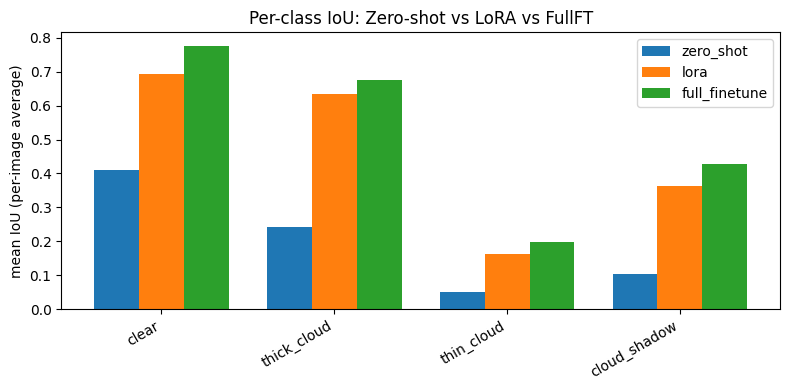

In [19]:
labels = [c.replace("iou_", "") for c in per_class_cols]
zs_means = [pd.to_numeric(miou_zs_p[c], errors="coerce").mean() for c in per_class_cols]
l_means = [pd.to_numeric(miou_lora_p[c], errors="coerce").mean() for c in per_class_cols]
f_means = [pd.to_numeric(miou_ft_p[c], errors="coerce").mean() for c in per_class_cols]

x = np.arange(len(labels))
w = 0.26

plt.figure(figsize=(8, 4))
plt.bar(x - w, zs_means, width=w, label="zero_shot")
plt.bar(x,      l_means, width=w, label="lora")
plt.bar(x + w,  f_means, width=w, label="full_finetune")
plt.xticks(x, labels, rotation=30, ha="right")
plt.ylabel("mean IoU (per-image average)")
plt.title("Per-class IoU: Zero-shot vs LoRA vs FullFT")
plt.legend()
plt.tight_layout()
plt.show()


In [20]:
paired = pd.DataFrame({
    "id": common_ids,
    "miou_zs": mzs.to_numpy(),
    "miou_lora": ml.to_numpy(),
    "miou_ft": mf.to_numpy(),
})

paired["delta_lora_vs_zs"] = paired["miou_lora"] - paired["miou_zs"]
paired["delta_ft_vs_zs"] = paired["miou_ft"] - paired["miou_zs"]
paired["delta_ft_vs_lora"] = paired["miou_ft"] - paired["miou_lora"]

paired.head()


,id,miou_zs,miou_lora,miou_ft,delta_lora_vs_zs,delta_ft_vs_zs,delta_ft_vs_lora
0,ROI_0001__20190212T142031_20190212T143214_T19FDF,0.259511,0.516004,0.603295,0.256492,0.343783,0.087291
1,ROI_0001__20190304T142031_20190304T142654_T19FDF,0.122684,0.225636,0.201725,0.102952,0.079041,-0.023911
2,ROI_0001__20190316T141049_20190316T142437_T19FDF,0.245935,0.487255,0.542263,0.241320,0.296327,0.055007
3,ROI_0001__20190525T141059_20190525T142053_T19FDF,0.193503,0.527044,0.514829,0.333541,0.321326,-0.012215
4,ROI_0001__20200308T141731_20200308T143551_T19FDF,0.191460,1.000000,1.000000,0.808540,0.808540,0.000000


In [21]:
print("Top improved (LoRA - ZS):")
paired.sort_values("delta_lora_vs_zs", ascending=False).head(10)


Top improved (LoRA - ZS):


,id,miou_zs,miou_lora,miou_ft,delta_lora_vs_zs,delta_ft_vs_zs,delta_ft_vs_lora
890,ROI_7640__20190111T073259_20190111T075530_T36KWU,0.0,1.0,1.000000,1.0,1.000000,0.000000
358,ROI_0949__20200304T160131_20200304T161939_T16PFT,0.0,1.0,1.000000,1.0,1.000000,0.000000
671,ROI_1661__20180320T092019_20180320T092416_T34SCC,0.0,1.0,1.000000,1.0,1.000000,0.000000
648,ROI_1423__20190918T182021_20190918T182459_T12STF,0.0,1.0,1.000000,1.0,1.000000,0.000000
752,ROI_3466__20191020T120649_20191020T120655_T24FXF,0.0,1.0,1.000000,1.0,1.000000,0.000000
786,ROI_4463__20200406T015649_20200406T015649_T55WFP,0.0,1.0,0.499620,1.0,0.499620,-0.500380
55,ROI_0120__20190302T045721_20190302T050545_T45TXE,0.0,1.0,1.000000,1.0,1.000000,0.000000
970,ROI_9795__20190506T063639_20190506T063634_T43WER,0.0,1.0,1.000000,1.0,1.000000,0.000000
514,ROI_11764__20200626T141741_20200626T143200_T19GCH,0.0,1.0,0.494379,1.0,0.494379,-0.505621
50,ROI_0106__20190509T152649_20190509T152958_T18LTN,0.0,1.0,1.000000,1.0,1.000000,0.000000


In [22]:
print("Top harmed (LoRA - ZS):")
paired.sort_values("delta_lora_vs_zs", ascending=True).head(10)


Top harmed (LoRA - ZS):


,id,miou_zs,miou_lora,miou_ft,delta_lora_vs_zs,delta_ft_vs_zs,delta_ft_vs_lora
138,ROI_0309__20191120T130249_20191120T130245_T24LTJ,1.000000,0.498747,0.498760,-0.501253,-0.501240,0.000013
289,ROI_0836__20200605T074621_20200605T080829_T35JNM,1.000000,0.499615,1.000000,-0.500385,0.000000,0.500385
244,ROI_0679__20200322T184031_20200322T184859_T11TNJ,0.617071,0.234690,0.500003,-0.382381,-0.117068,0.265313
508,ROI_1174__20190824T142751_20190824T142754_T20MMT,0.413019,0.087337,0.062836,-0.325682,-0.350183,-0.024502
500,ROI_11670__20190306T070749_20190306T070745_T43WDQ,0.331935,0.081871,0.139114,-0.250064,-0.192820,0.057243
120,ROI_0268__20190129T071209_20190129T071208_T38KNV,0.494802,0.247308,0.549600,-0.247493,0.054798,0.302292
208,ROI_0535__20200307T184219_20200307T184220_T11TPN,0.230988,0.023281,0.060783,-0.207707,-0.170205,0.037502
328,ROI_0908__20200609T151709_20200609T151945_T18PZT,0.460203,0.322241,0.488554,-0.137962,0.028351,0.166313
157,ROI_0362__20190929T202229_20190929T202710_T08VNL,0.152501,0.033108,0.002937,-0.119393,-0.149564,-0.030171
857,ROI_6213__20190724T145731_20190724T145730_T19PGP,0.445831,0.327643,0.536654,-0.118188,0.090822,0.209011


In [23]:
print("Top improved (FullFT - ZS):")
paired.sort_values("delta_ft_vs_zs", ascending=False).head(10)


Top improved (FullFT - ZS):


,id,miou_zs,miou_lora,miou_ft,delta_lora_vs_zs,delta_ft_vs_zs,delta_ft_vs_lora
807,ROI_4797__20191220T092309_20191220T092838_T34RDT,0.0,0.315126,1.0,0.315126,1.0,0.684874
952,ROI_9277__20190502T083609_20190502T084027_T37VFK,0.0,1.000000,1.0,1.000000,1.0,0.000000
648,ROI_1423__20190918T182021_20190918T182459_T12STF,0.0,1.000000,1.0,1.000000,1.0,0.000000
719,ROI_2780__20200404T075609_20200404T082657_T35HLB,0.0,1.000000,1.0,1.000000,1.0,0.000000
297,ROI_0868__20200417T071621_20200417T072348_T39TWF,0.0,1.000000,1.0,1.000000,1.0,0.000000
340,ROI_0930__20180601T102021_20180601T102024_T33VVF,0.0,0.497261,1.0,0.497261,1.0,0.502739
349,ROI_0936__20200606T080609_20200606T083047_T35LPK,0.0,1.000000,1.0,1.000000,1.0,0.000000
752,ROI_3466__20191020T120649_20191020T120655_T24FXF,0.0,1.000000,1.0,1.000000,1.0,0.000000
358,ROI_0949__20200304T160131_20200304T161939_T16PFT,0.0,1.000000,1.0,1.000000,1.0,0.000000
960,ROI_9761__20190120T035051_20190120T035439_T48TYT,0.0,0.489529,1.0,0.489529,1.0,0.510471


In [24]:
print("Top harmed (FullFT - ZS):")
paired.sort_values("delta_ft_vs_zs", ascending=True).head(10)


Top harmed (FullFT - ZS):


,id,miou_zs,miou_lora,miou_ft,delta_lora_vs_zs,delta_ft_vs_zs,delta_ft_vs_lora
138,ROI_0309__20191120T130249_20191120T130245_T24LTJ,1.000000,0.498747,0.498760,-0.501253,-0.501240,0.000013
914,ROI_8676__20200405T104619_20200405T105015_T30TYT,1.000000,1.000000,0.499525,0.000000,-0.500475,-0.500475
294,ROI_0846__20200719T031539_20200719T032500_T49TFF,1.000000,1.000000,0.499870,0.000000,-0.500130,-0.500130
508,ROI_1174__20190824T142751_20190824T142754_T20MMT,0.413019,0.087337,0.062836,-0.325682,-0.350183,-0.024502
500,ROI_11670__20190306T070749_20190306T070745_T43WDQ,0.331935,0.081871,0.139114,-0.250064,-0.192820,0.057243
889,ROI_7063__20200224T075919_20200224T082412_T35JNK,0.468375,0.401919,0.280145,-0.066455,-0.188230,-0.121775
208,ROI_0535__20200307T184219_20200307T184220_T11TPN,0.230988,0.023281,0.060783,-0.207707,-0.170205,0.037502
589,ROI_1322__20200714T070231_20200714T070231_T38KRG,0.499994,1.000000,0.331041,0.500006,-0.168954,-0.668959
157,ROI_0362__20190929T202229_20190929T202710_T08VNL,0.152501,0.033108,0.002937,-0.119393,-0.149564,-0.030171
59,ROI_0120__20191219T045209_20191219T045214_T45TXE,0.329294,0.333314,0.204809,0.004021,-0.124484,-0.128505
